In [2]:
import numpy as np
import orbitengine.engine as oe
import astropy.units as u
from poliastro.bodies import Earth
from poliastro.twobody import Orbit
from scipy.optimize import minimize
import orbitengine.trajectorysegment as ts
from orbitengine.body import Body
import time
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from poliastro import iod
import pickle
import math
import os
import uuid

earth_k = Earth.k.to(u.km**3/u.s**2)
earth_axis_angle = [0,0,2*np.pi/(24*3600)]*u.rad/u.s


class TransferSolver:
    def __init__(self, state_init, state_target, k, time_weight=0.0005):
        self.state_init = state_init
        self.state_target = state_target
        self.k = k
        self.time_weight = time_weight
        self.dv1 = None
        self.dv2 = None
        self.uuid = uuid.uuid4()

    def transfer_dv(self, x):
        t_delay, t_flight = x
        t_delay *= u.s
        t_flight *= u.s

        init_pre_transfer = self.state_init.propagate(earth_k, t_delay)
        target_post_transfer = self.state_target.propagate(earth_k, t_delay+t_flight)

        res = list(iod.izzo.lambert(Earth.k, init_pre_transfer.position, target_post_transfer.position, t_flight, M=0))
        if len(res) == 0 or len(res) > 1:
            print(f"lambert produced {len(res)} solutions")
        v0_sol, v1_sol = res[0]

        ground_penalty = 0
        #add cost for not being aligned with the surface normal on launch
        if self.state_init.parent_axis_angle is not None:
            ndot = np.dot(v0_sol/np.linalg.norm(v0_sol), init_pre_transfer.position/np.linalg.norm(init_pre_transfer.position))
            # must point slightly upwards from the surface
            if ndot < 0.1:
                ground_penalty = 10000  # arbitrary large number, is this sufficient?

        #add cost for not being aligned with the surface normal on land
        if self.state_target.parent_axis_angle is not None:
            ndot = np.dot(v1_sol/np.linalg.norm(v1_sol), target_post_transfer.position/np.linalg.norm(target_post_transfer.position))
            # must point slightly upwards from the surface
            if ndot < 0.1:
                ground_penalty = 10000

        dv1 = np.linalg.norm(v0_sol - init_pre_transfer.velocity).value
        dv2 = np.linalg.norm(v1_sol - target_post_transfer.velocity).value
        self.dv1 = dv1
        self.dv2 = dv2        
        dt = (t_delay+t_flight).value*self.time_weight

        return dv1*dv1+dv2*dv2+dt*dt + ground_penalty
    
    def lambert_search(self, min_delay=1, max_delay=None, min_tof=1, max_tof=None, resolution=5, plot=False):
        init_period = self.state_init.period(earth_k)
        target_period = self.state_target.period(earth_k)
        max_time = 10000*u.s
        if not np.isnan(init_period) and not np.isnan(target_period):
            if init_period > target_period:
                max_time = init_period
            else:
                max_time = target_period

        #use priods to define search bounds
        if max_tof is None:
            max_tof = max_time.value
        if max_delay is None:
            max_delay = max_time.value
        flight_times = np.linspace(min_tof, max_tof, resolution)*u.s
        delay_times = np.linspace(min_delay, max_delay, resolution)*u.s
        dv = np.zeros((len(delay_times), len(flight_times)))

        for delay_idx in range(len(delay_times)):
            for tof_idx in range(len(flight_times)):
                try:
                    res = self.transfer_dv([
                        delay_times[delay_idx].value, 
                        flight_times[tof_idx].value])
                    dv[tof_idx,delay_idx] = np.log(res)
                except Exception as e:
                    dv[tof_idx,delay_idx] = 9


        #init guess based on sampling
        min_indices = np.unravel_index(np.argmin(dv), dv.shape)
        t_delay_min_dv = delay_times[min_indices[1]]
        t_flight_min_dv = flight_times[min_indices[0]]

        # optimize minimum dv from initial guess
        x0 = [t_delay_min_dv.value,t_flight_min_dv.value]
        bounds = [[0, max_delay], [1, max_tof]]
        res = minimize(self.transfer_dv, x0, bounds=bounds)
        self.t_delay = res.x[0]*u.s
        self.t_flight = res.x[1]*u.s
        dv_minimum = res.fun

        init_pre_transfer = self.state_init.propagate(self.k, self.t_delay)
        target_post_transfer = self.state_target.propagate(earth_k, self.t_delay+self.t_flight)

        r1 = init_pre_transfer.position
        r2 = target_post_transfer.position
        res = list(iod.izzo.lambert(Earth.k, r1, r2, self.t_flight, M=0))
        v1_sol = res[0][0]
        self.state_transfer = Body.State(r1, v1_sol, self.state_init.mass, self.state_init.tempurature, self.t_delay)

        if plot:
            fig, axs = plt.subplots(1, 2, figsize=(10, 5))

            # Plot dv grid as image --------------------------
            axs[0].imshow(dv, cmap='plasma', origin='lower', extent=[delay_times.min().value, delay_times.max().value, flight_times.min().value, flight_times.max().value])

            # show color scale
            cbar = plt.colorbar(axs[0].imshow(dv, cmap='plasma', origin='lower', extent=[delay_times.min().value, delay_times.max().value, flight_times.min().value, flight_times.max().value]))
            cbar.set_label('log(dv)')

            axs[0].set_ylabel('tof')
            axs[0].set_xlabel('delay')
            axs[0].set_title('Lambert DV')
            axs[0].grid(True)
            axs[0].set_aspect('auto', adjustable='box')

            axs[0].plot(t_delay_min_dv, t_flight_min_dv,  'ro') # init guess
            axs[0].plot(self.t_delay, self.t_flight,  'go') # final optimized

            # init positions --------------------------
            positions_init = []
            for t in np.linspace(0, self.t_delay, 100):
                s = self.state_init.propagate(self.k,t)
                positions_init.append(s.position)
            axs[1].plot([p[0].value for p in positions_init], [p[1].value for p in positions_init], label='Init')

            # transfer positions --------------------------
            positions_transfer = []
            for t in np.linspace(0, self.t_flight, 100):
                positions_transfer.append(self.state_transfer.propagate(self.k,t).position)
            axs[1].plot([p[0].value for p in positions_transfer], [p[1].value for p in positions_transfer], label='Transfer')

            # target positions --------------------------
            positions_target = []
            for t in np.linspace(0, 100*u.s, 100):
                s = self.state_target.propagate(self.k,self.t_delay + self.t_flight + t)
                positions_target.append(s.position)
            axs[1].plot([p[0].value for p in positions_target], [p[1].value for p in positions_target], label='Target')

            circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM.value, color='b', fill=False, linestyle='dotted')
            axs[1].add_artist(circle)
            axs[1].set_aspect('equal', adjustable='box')
            plt.show()
        return dv_minimum, self.t_delay, self.t_flight, self.state_transfer
    
    def compute_thrust_maneuvers(self, flow_rate, isp, dry_mass, alignment_tol=0.01, verbose=False):
        # compute first thrust maneuver
        m1_filename = f"transfer_m1_{self.uuid}.pkl"
        m2_filename = f"transfer_m2_{self.uuid}.pkl"
        if os.path.exists(m1_filename):
            with open(m1_filename, 'rb') as f:
                self.maneuver1 = pickle.load(f)
        else:
            self.maneuver1 = ThrustManeuver(self.state_init, self.state_transfer, self.k, self.t_delay, flow_rate, isp, dry_mass)
            err = self.maneuver1.optimize(verbose=verbose)
            if err > alignment_tol:
                print(f"Maneuver 1 failed to achieve trajectory alignment: {err:.05f} > {alignment_tol}")
                print(f"State post Maneuver 1:\n{self.maneuver1.state_post_maneuver}")

            with open(m1_filename, 'wb') as f:
                pickle.dump(self.maneuver1, f)
                print(f"saved to {m1_filename}")

        # compute second thrust maneuver
        state_target_post_transfer = self.state_target.propagate(self.k, self.t_delay + self.t_flight)
        self.state_transfer.mass = self.maneuver1.state_post_maneuver.mass

        if os.path.exists(m2_filename):
            with open(m2_filename, 'rb') as f:
                self.maneuver2 = pickle.load(f)
        else:
            self.maneuver2 = ThrustManeuver(self.state_transfer, state_target_post_transfer, self.k, self.t_flight, flow_rate, isp, dry_mass)
            err = self.maneuver2.optimize(verbose=verbose)
            print(f"Maneuver 2 alignment error: {err:.05f}")
            if err > alignment_tol:
                print(f"Maneuver 2 failed to achieve trajectory alignment: {err:.05f} > {alignment_tol}")
                print(f"State post Maneuver 2:\n{self.maneuver2.state_post_maneuver}")

            with open(m2_filename, 'wb') as f:
                pickle.dump(self.maneuver2, f)
                print(f"saved to {m2_filename}")

        self.state_post_thrust_transfer = self.maneuver2.state_post_maneuver
        return self.state_post_thrust_transfer

    def plot_thrust_transfer_trajectory(self, show_maneuvers=False):
        if show_maneuvers:
            self.maneuver1.plot()
            self.maneuver1.plot_components()
            print(f"Post Maneuver Mass: {self.maneuver1.state_post_maneuver.mass}")
            self.maneuver2.plot()
            self.maneuver2.plot_components()
            print(f"Post Maneuver Mass: {self.maneuver2.state_post_maneuver.mass}")

        # plot the entire trajectory
        states_tween = []
        for t in np.linspace(self.maneuver1.t_correction_burn, self.t_flight-self.maneuver2.t_init_burn, 50):
            s = self.state_transfer.propagate(earth_k, t)
            states_tween.append(s)
        states_m1 = self.maneuver1.states()
        states_m2 = self.maneuver2.states()
        self.states_thrust_transfer = states_m1 + states_tween + states_m2
        fig, axs = plt.subplots(1, 1, figsize=(10, 10))

        axs.plot([s.position[0].value for s in self.states_thrust_transfer], [s.position[1].value for s in self.states_thrust_transfer])

        p = states_m1[0].position
        axs.plot(p[0], p[1], 'ro')
        p = states_m1[-1].position
        axs.plot(p[0], p[1], 'ro')

        p = states_m2[0].position
        axs.plot(p[0], p[1], 'go')
        p = states_m2[-1].position
        axs.plot(p[0], p[1], 'go')

        circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM.value, color='b', fill=False, linestyle='dotted')
        axs.add_artist(circle)
        axs.set_aspect('equal', adjustable='box')
        plt.show()

        return self.state_post_thrust_transfer


class ThrustManeuver:
    def __init__(self, 
                 state_init, 
                 state_target, 
                 k, 
                 t_maneuver, 
                 flow_rate, 
                 isp, 
                 dry_mass):
        self.state_init = state_init  # state prior to the maneuver along which t_manuever if propagated
        self.state_target = state_target # target state post maneuver calculated from t_maneuver forward
        self.k = k # gravitational parameter
        self.t_maneuver = t_maneuver # time of the instaneous maneuver
        self.flow_rate = flow_rate # mass flow rate
        self.isp = isp # specific impulse
        self.state_post_maneuver = None
        self.mass_dry = dry_mass

    def maneuver_err(self, x):
        t_init_burn = x[0]*u.s
        t_correction_burn = x[1]*u.s
        thrust_vec_init = R.from_rotvec([0,0,x[2]]).apply(oe.ZERO_ANGLE_VECTOR)
        thrust_vec_correction = R.from_rotvec([0,0,x[3]]).apply(oe.ZERO_ANGLE_VECTOR)

        acc_param_init = oe.AccParams(thrust_vec=thrust_vec_init,
                                reaction_flow_rate=self.flow_rate,
                                reaction_isp=self.isp,
                                mass_dry=self.mass_dry)
        acc_param_correction = oe.AccParams(thrust_vec=thrust_vec_correction,
                                reaction_flow_rate=self.flow_rate,
                                reaction_isp=self.isp,
                                mass_dry=self.mass_dry)
        s0 = self.state_init.propagate(self.k, self.t_maneuver - t_init_burn)
        s1a = s0.propagate(self.k, t_init_burn, acc_params=acc_param_init)
        s1 = s1a.propagate(self.k, t_correction_burn, acc_params=acc_param_correction)

        self.state_post_maneuver = s1
        s2 = self.state_target.propagate(self.k, t_correction_burn)
        dr = np.linalg.norm(s1.position - s2.position).value
        dv = np.linalg.norm(s1.velocity - s2.velocity).value
        return dr*dr + dv*dv

    def to_dict(self):
        return {
            'state_init': self.state_init.__dict__,
            'state_target': self.state_target.__dict__,
            'state_post_maneuver': self.state_post_maneuver.__dict__,
            'k': self.k,
            't_maneuver': self.t_maneuver,
            'flow_rate': self.flow_rate,
            'isp': self.isp,
            'mass_dry': self.mass_dry,
        }

    def optimize(self, verbose=False):

        state_intercept = self.state_init.propagate(self.k, self.t_maneuver)

        #initial guess
        maneuver_dv = np.linalg.norm(self.state_target.velocity - state_intercept.velocity)

        acc = oe.EARTH_G0*self.isp * self.flow_rate/self.state_init.mass        
        t_init_burn = 0.25*maneuver_dv/acc  # 0.5 seemed to put it in a local minimum
        t_correction_burn = 1*t_init_burn
        maneuver_angle = math.atan2(self.state_target.velocity[1].value, self.state_target.velocity[0].value)
        launch_thrust_angle = maneuver_angle
        correction_thrust_angle = maneuver_angle

        x = [t_init_burn.value, t_correction_burn.value, launch_thrust_angle,correction_thrust_angle]

        res = minimize(self.maneuver_err, x, method='Nelder-Mead', options={'maxiter': 5000}) 
        if verbose:
            print(f"Initial guess: {x}")
            print(res)
        self.t_init_burn = res.x[0]*u.s
        self.t_correction_burn = res.x[1]*u.s
        self.launch_thrust_angle = res.x[2]
        self.correction_thrust_angle = res.x[3]
        self.alignment_err = res.fun
        return res.fun
    
    def states(self, count=50):
        # rocket trajectory
        states_maneuver = []
        thrust_vec_init = R.from_rotvec([0,0,self.launch_thrust_angle]).apply(oe.ZERO_ANGLE_VECTOR)
        thrust_vec_correction = R.from_rotvec([0,0,self.correction_thrust_angle]).apply(oe.ZERO_ANGLE_VECTOR)
        acc_param_init_burn = oe.AccParams(thrust_vec=thrust_vec_init,
                                    reaction_flow_rate=self.flow_rate,
                                    reaction_isp=self.isp)
        acc_param_correction_burn = oe.AccParams(thrust_vec=thrust_vec_correction,
                                    reaction_flow_rate=self.flow_rate,
                                    reaction_isp=self.isp)

        state_init_burn = self.state_init.propagate(self.k, self.t_maneuver - self.t_init_burn)

        # rocket trajectory
        for t in np.linspace(0, self.t_init_burn, int(count/2)):
            s = state_init_burn.propagate(self.k,t, acc_params=acc_param_init_burn)
            states_maneuver.append(s)
        state_correction_burn = states_maneuver[-1]
        for t in np.linspace(0, self.t_correction_burn, int(count/2)):
            s = state_correction_burn.propagate(self.k,t, acc_params=acc_param_correction_burn)
            states_maneuver.append(s)  

        return states_maneuver

    def plot_components(self):
        # plot components of the flight
        fig, axs = plt.subplots(nrows=4, sharex=True, figsize=(10,10))
        states_maneuver = self.states()
        accel = []
        for i in range(len(states_maneuver)-1):
            s1 = states_maneuver[i]
            s2 = states_maneuver[i+1]
            a = np.linalg.norm(s2.velocity-s1.velocity).value/(s2.timestamp - s1.timestamp).value
            accel.append(a)
        accel.append(accel[-1]) # pad to be equal length

        times = [s.timestamp.value for s in states_maneuver]-self.t_maneuver.value
        axs[0].plot(times, [np.linalg.norm(s.position).value - oe.EARTH_RADIUS_KM.value for s in states_maneuver])
        axs[0].title.set_text('Altitude')
        axs[1].plot(times, [np.linalg.norm(s.velocity).value for s in states_maneuver])
        axs[1].title.set_text('Velocity')
        axs[2].plot(times, [s.mass.value for s in states_maneuver])
        axs[2].title.set_text('Mass')
        axs[3].plot(times, accel)
        axs[3].title.set_text('Acceleration')
        plt.show()

    def plot(self):
        # compute and plot body trajectories
        positions_init = []
        positions_target = []

        states_maneuver = self.states()

        # init trajectory
        for t in np.linspace(self.t_maneuver-self.t_init_burn, self.t_maneuver, 50):
            s = self.state_init.propagate(self.k,t)
            positions_init.append(s.position)

        #target trajectory
        for t in np.linspace(0, self.t_correction_burn, 50):
            s = self.state_target.propagate(self.k, t)
            positions_target.append(s.position)

        fig, axs = plt.subplots(1, 1, figsize=(10, 10))
        axs.plot([p[0].value for p in positions_init], [p[1].value for p in positions_init], label='Init')
        axs.plot([p[0].value for p in positions_target], [p[1].value for p in positions_target], label='Target')
        axs.plot([s.position[0].value for s in states_maneuver], [s.position[1].value for s in states_maneuver], label='Maneuver')

        p = states_maneuver[0].position
        axs.plot(p[0], p[1], 'ro')

        p = self.state_target.position
        axs.plot(p[0], p[1], 'bo')

        p = self.state_post_maneuver.position
        axs.plot(p[0], p[1], 'go')

        circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM.value, color='b', fill=False, linestyle='dotted')
        axs.add_artist(circle)
        axs.set_aspect('equal', adjustable='box')

        plt.show()

In [3]:
# rocket on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
ground_velocity = oe.EARTH_RADIUS_KM*2*np.pi/(24*3600*u.s)
v0 = np.array([0, ground_velocity.value, 0])*u.km/u.s
m0 = 100000*u.kg # rocket + fuel
dry_mass =  oe.ROCKET_DRY_MASS
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
state_launch = Body.State( r0, v0, m0, T0, parent_axis_angle=earth_axis_angle)

# compute a target in circular orbit
r_target = np.array([0, 400+oe.EARTH_RADIUS_KM.value, 0])*u.km # ISS
res = minimize(oe.eccentricity, np.array([-5.59,0 , 0]), args=(r_target.value, earth_k.value))
state_leo = Body.State(r_target, res.x*u.km/u.s, m0, T0)

r_target = np.array([0, 35786+oe.EARTH_RADIUS_KM.value, 0])*u.km # geostationary
res = minimize(oe.eccentricity, np.array([-5.59,0 , 0]), args=(r_target.value, earth_k.value))
state_geo = Body.State(r_target, res.x*u.km/u.s, m0, T0)

# solve transfer

import glob
transfer_filename = 'transfer_*.pkl'
if glob.glob(transfer_filename):
    with open(glob.glob(transfer_filename)[0], 'rb') as f:
        solver = pickle.load(f)
        print(f"loaded from {glob.glob(transfer_filename)[0]}")
else:
    #solver = TransferSolver(state_launch, state_leo, earth_k, time_weight=0.000)
    solver = TransferSolver(state_leo, state_geo, earth_k, time_weight=0.0001)
    print(solver.lambert_search(resolution=10, plot=True))
    transfer_filename = f"transfer_{solver.uuid}.pkl"
    with open(transfer_filename, 'wb') as f:
        pickle.dump(solver, f)
        print(f"saved to {transfer_filename}")

print(f"Transfer: dv1: {solver.dv1:.02f} dv2: {solver.dv2:.02f} t_delay: {solver.t_delay} t_flight: {solver.t_flight}")




loaded from transfer_9c0e6118-276b-455e-997e-bdaae041749a.pkl
Transfer: dv1: 2.43 dv2: 1.67 t_delay: 10113.733589224885 s t_flight: 14946.191493248018 s


Timestamp: 25265.919640909877 s
Position: [-40618.16333433 -11312.64646055      0.        ] km
Velocity: [ 0.82493328 -2.96193086  0.        ] km / s
Mass: 38243.03842358446 kg
Tempurature: 732.7932098347591 K

Reaction Mass Remaining: 38233.03842358446 kg
Delay, Flight: 10113.733589224885 s 14946.191493248018 s
m1: 606.8565438895228 s 497.4243400315422 s 1.4239463257285618e-13
m2: 233.6486513977836 s 205.99455843697524 s 1.8723924569259256e-13


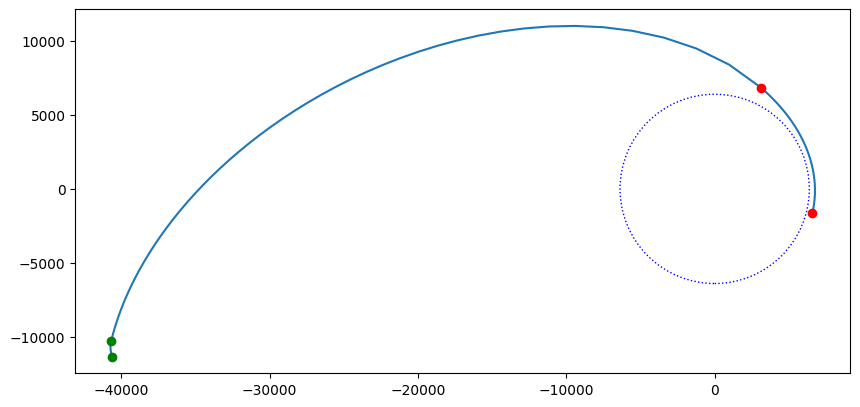

In [9]:
# compute thrust limited maneuvers
flow_rate = 50.0*oe.REACTION_MASS_FLOW_RATE

# delete files ending in .pkl
# for filename in os.listdir():
#     if filename.startswith("transfer_m"):
#         os.remove(filename)
#         print(f"deleted {filename}")

res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=True)
if res is not None:
    print(res)
    print("Reaction Mass Remaining:", res.mass - dry_mass)
    print("Delay, Flight:", solver.t_delay, solver.t_flight)
    print("m1:", solver.maneuver1.t_init_burn, solver.maneuver1.t_correction_burn, solver.maneuver1.alignment_err)
    print("m2:", solver.maneuver2.t_init_burn, solver.maneuver2.t_correction_burn, solver.maneuver2.alignment_err)
    solver.plot_thrust_transfer_trajectory(show_maneuvers=False)


In [5]:
from pprint import pprint

pprint(solver.maneuver2.to_dict())

{'flow_rate': <Quantity 16. kg / s>,
 'isp': <Quantity 450. s>,
 'k': <Quantity 398600.4418 km3 / s2>,
 'mass_dry': <Quantity 10. kg>,
 'state_init': {'mass': <Quantity 48518.98318325 kg>,
                'parent_axis_angle': None,
                'position': <Quantity [6112.49871811, 2929.13685208,    0.        ] km>,
                'tempurature': <Quantity 293.15 K>,
                'timestamp': <Quantity 10113.73358922 s>,
                'velocity': <Quantity [-4.38152849,  9.10111531,  0.        ] km / s>},
 'state_post_maneuver': {'mass': <Quantity 32660.53655508 kg>,
                         'parent_axis_angle': None,
                         'position': <Quantity [-40380.53327747, -12133.57727871,      0.        ] km>,
                         'tempurature': <Quantity 1284.30291426 K>,
                         'timestamp': <Quantity 25543.88400148 s>,
                         'velocity': <Quantity [ 0.90820024, -3.02650186,  0.        ] km / s>},
 'state_target': {'mass': <Qua